In [328]:
#take in all imports I will use for this project
import matplotlib.pyplot as plt 
import pandas as pd 
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [329]:
#read dataframe
food_ingredient_analysis = pd.read_csv("Food Ingredients and Recipe Dataset with Image Name Mapping.csv")

food_ingredient_analysis.head()

,Unnamed: 0,Title,Ingredients,Instructions,Image_Name,Cleaned_Ingredients
0,0,Miso-Butter Roast Chicken With Acorn Squash Pa...,"['1 (3½–4-lb.) whole chicken', '2¾ tsp. kosher...","Pat chicken dry with paper towels, season all ...",miso-butter-roast-chicken-acorn-squash-panzanella,"['1 (3½–4-lb.) whole chicken', '2¾ tsp. kosher..."
1,1,Crispy Salt and Pepper Potatoes,"['2 large egg whites', '1 pound new potatoes (...",Preheat oven to 400°F and line a rimmed baking...,crispy-salt-and-pepper-potatoes-dan-kluger,"['2 large egg whites', '1 pound new potatoes (..."
2,2,Thanksgiving Mac and Cheese,"['1 cup evaporated milk', '1 cup whole milk', ...",Place a rack in middle of oven; preheat to 400...,thanksgiving-mac-and-cheese-erick-williams,"['1 cup evaporated milk', '1 cup whole milk', ..."
3,3,Italian Sausage and Bread Stuffing,"['1 (¾- to 1-pound) round Italian loaf, cut in...",Preheat oven to 350°F with rack in middle. Gen...,italian-sausage-and-bread-stuffing-240559,"['1 (¾- to 1-pound) round Italian loaf, cut in..."
4,4,Newton's Law,"['1 teaspoon dark brown sugar', '1 teaspoon ho...",Stir together brown sugar and hot water in a c...,newtons-law-apple-bourbon-cocktail,"['1 teaspoon dark brown sugar', '1 teaspoon ho..."


In [330]:
#understand data
food_ingredient_analysis.describe()

,Unnamed: 0
count,13501.000000
mean,6750.000000
std,3897.547327
min,0.000000
25%,3375.000000
50%,6750.000000
75%,10125.000000
max,13500.000000


In [331]:
food_ingredient_analysis.shape

(13501, 6)

In [332]:
food_ingredient_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13501 entries, 0 to 13500
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Unnamed: 0           13501 non-null  int64 
 1   Title                13496 non-null  object
 2   Ingredients          13501 non-null  object
 3   Instructions         13493 non-null  object
 4   Image_Name           13501 non-null  object
 5   Cleaned_Ingredients  13501 non-null  object
dtypes: int64(1), object(5)
memory usage: 633.0+ KB


In [333]:
#data preprocessing
#check for missing values
food_ingredient_analysis.isnull().sum()

Unnamed: 0             0
Title                  5
Ingredients            0
Instructions           8
Image_Name             0
Cleaned_Ingredients    0
dtype: int64

In [334]:
 #drop rows with null values
food_ingredient_analysis = food_ingredient_analysis.dropna()

In [335]:
#drop and clean up data
# drop irrevelant coloums like instruction , unnamed, image name
food_ingredient_analysis = food_ingredient_analysis.drop(columns=['Instructions', 'Unnamed: 0', 'Image_Name', 'Ingredients'], errors='ignore')

In [336]:
food_ingredient_analysis.head()

,Title,Cleaned_Ingredients
0,Miso-Butter Roast Chicken With Acorn Squash Pa...,"['1 (3½–4-lb.) whole chicken', '2¾ tsp. kosher..."
1,Crispy Salt and Pepper Potatoes,"['2 large egg whites', '1 pound new potatoes (..."
2,Thanksgiving Mac and Cheese,"['1 cup evaporated milk', '1 cup whole milk', ..."
3,Italian Sausage and Bread Stuffing,"['1 (¾- to 1-pound) round Italian loaf, cut in..."
4,Newton's Law,"['1 teaspoon dark brown sugar', '1 teaspoon ho..."


In [337]:
food_ingredient_analysis.head()

,Title,Cleaned_Ingredients
0,Miso-Butter Roast Chicken With Acorn Squash Pa...,"['1 (3½–4-lb.) whole chicken', '2¾ tsp. kosher..."
1,Crispy Salt and Pepper Potatoes,"['2 large egg whites', '1 pound new potatoes (..."
2,Thanksgiving Mac and Cheese,"['1 cup evaporated milk', '1 cup whole milk', ..."
3,Italian Sausage and Bread Stuffing,"['1 (¾- to 1-pound) round Italian loaf, cut in..."
4,Newton's Law,"['1 teaspoon dark brown sugar', '1 teaspoon ho..."


In [338]:
import re

# custom specific stop words that relate to ingredients 
# since im using text i have to remove world that have info about the details of size of ingredients and other irrelevant words
custom_stop_words_list = [
    'cup','cups','teaspoon','teaspoons','tablespoon','tablespoons','tbsp','tsp',
    'oz','ounce','ounces','pound','pounds','lb','grams','g','kg','ml',
    'liter','liters','clove','cloves','clov','pinch','dash','to taste','stick',
    'chopped','sliced','diced','minced','fresh','freshly','dried','ground',
    'finely','large','small','medium','whole','optional','divided','plus',
    'to','round','into','about','diameter','more','total','in','cut',
    'cubes','inch','bias','thinly','peeled','halved','pitted','seeded',
    'softened','melted','unsalted','salted','heavy','extra virgin','extra virgin olive',
    'room temperature','temperature','kosher','granulated','powder','purpose',"zest", 
    'zested','piec','vegetable','grated','powdered','toasted','new',"additional", "brushing", "drizzling",
    "dusting", "dry", "active", "yeast"
    'can','package','jar','bottle','bag','box','carton','pack',
    'pan','cutter','thermometer','processor','blade','slicer','slice','knife',
    'spoon','fork','bowl','dish','dishes','tray','sheet','plate','skillet',
    'pot','oven','microwave',
    'bake','baked','baking','boil','boiled','boiling','fry','fried','frying',
    'roast','roasted','roasting','grill','grilled','grilling','saute','sauteed',
    'steam','steamed','mix','mixed','mixing','stir','stirred','stirring',
    'blend','blended','blending','whisk','whisked','whisking',"lightly", "sweetened", "absinthe", 
    "accompaniment", "wedge","garnish", "piece" "pieces", "all", "pure"
    'zest','juice','juiced','water','broth','stock','sauce','oil','vinegar',
    'olive oil','olive',
    'salt','sugar','flour','butter','seeds','seed',
    'and','of','deep','need','needed','food','with','on','for','by'
    'chilled','rimmed','cored','patted','drained','lengthwise','rinsed',
    'trimmed','crosswise thirds','tough ends trimmed','cooled','firmly packed',
    'mortar pestle','nonstick spray','instant read',
    'superfine','white','sticks','sprigs','tender stems','unbleached','warm',
    'packed dark brown','confectioners','table','sea cracked', "adjustable", "allspice", "pieces"
]

# cleaning text function
def clean_and_normalize_ingredients(ingredient_text):
    if not isinstance(ingredient_text, str):
        return ""
    
    # lowercase text
    text = ingredient_text.lower()


    # remove numbers 
    text = re.sub(r'\s*\d+[\/\.\d]*\s*', ' ', text)
    
    # remove stop words
    for word in custom_stop_words_list:
        if ' ' in word: 
            text = text.replace(word, ' ')
        else:          
            text = re.sub(r'\b' + re.escape(word) + r'\b', ' ', text)
        
    # remove non-alphabetic characters except commas
    text = re.sub(r'[^a-z,]', ' ', text)  
    
    # helps space
    text = re.sub(r'\s+', ' ', text).strip()
    
    # normalize commas
    text = re.sub(r'\s*,\s*', ',', text)  
    text = re.sub(r',+', ',', text)     
    
    # remove commas at start/end
    text = text.strip(',')
    
    # remove along single letters
    text = re.sub(r'\b[a-z]\b', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    #remove short words 1 to 2 char
    text = re.sub(r'\b[a-z]{1,2}\b', '', text)

    return text

# apply the function to your column
food_ingredient_analysis['Final_Ingredients_Clean'] = food_ingredient_analysis['Cleaned_Ingredients'].apply(
    clean_and_normalize_ingredients
)

In [339]:
food_ingredient_analysis.head()

,Title,Cleaned_Ingredients,Final_Ingredients_Clean
0,Miso-Butter Roast Chicken With Acorn Squash Pa...,"['1 (3½–4-lb.) whole chicken', '2¾ tsp. kosher...","chicken,acorn squash,sage,rosemary,crushed red..."
1,Crispy Salt and Pepper Potatoes,"['2 large egg whites', '1 pound new potatoes (...","egg whites,potatoes,black pepper,rosemary,thym..."
2,Thanksgiving Mac and Cheese,"['1 cup evaporated milk', '1 cup whole milk', ...","evaporated milk,milk,garlic,onion,smoked papri..."
3,Italian Sausage and Bread Stuffing,"['1 (¾- to 1-pound) round Italian loaf, cut in...","italian loaf,sweet italian sausage,casings rem..."
4,Newton's Law,"['1 teaspoon dark brown sugar', '1 teaspoon ho...","dark brown,hot,bourbon,lemon,apple storebought..."


In [340]:
# do vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    tokenizer=lambda x: [t.strip() for t in x.split(',') if t.strip()],
    stop_words=custom_stop_words_list,
    max_df=0.5,
    min_df=10,
    max_features=5000,
    use_idf=True
)

X_tfidf = vectorizer.fit_transform(food_ingredient_analysis['Final_Ingredients_Clean'])
print("TF-IDF matrix shape:", X_tfidf.shape)


TF-IDF matrix shape: (13493, 1381)


/Users/dishanariani/Desktop/PROJECTS/PROJECT4DATAMINING/.venv/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


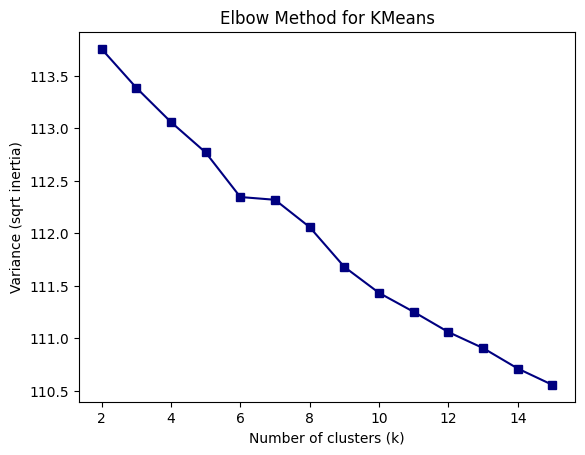

In [341]:
# find ineratia
inertia = []

for k in range(2, 16):
    kmeans = KMeans(n_clusters=k, random_state=1, n_init='auto').fit(X_tfidf)
    inertia.append(np.sqrt(kmeans.inertia_))

plt.plot(range(2, 16), inertia, marker='s', color='navy')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Variance (sqrt inertia)")
plt.title("Elbow Method for KMeans")
plt.show()

In [342]:
# according to graph i think 6 is ideal because thats when it starts dropping more
# do k means
kmeans = KMeans(n_clusters=6, random_state=42, n_init='auto')
kmeans.fit(X_tfidf)

# Assign cluster labels to your data
food_ingredient_analysis['Cluster'] = kmeans.labels_

# Get feature names
feature_names = vectorizer.get_feature_names_out()


In [343]:
# this doesnt show all but it prints them from a to z
print("TF-IDF feature names:")
print(feature_names)
# After fitting KMeans this will label all 13000+ recipes into a cluster 
# it doesnt show all but it prints like the label num for each recipe from each row
print("Cluster labels for each recipe:")
print(kmeans.labels_)

TF-IDF feature names:
['acorn squash' 'adobo' 'agave nectar' ... 'yukon gold potatoes' 'zaatar'
 'zucchini']
Cluster labels for each recipe:
[5 5 5 ... 1 1 2]


In [344]:
# Count how many recipes are in each cluster
cluster_sizes = np.bincount(kmeans.labels_)

# Print sizes
for i, size in enumerate(cluster_sizes):
    print(f"Cluster {i}: {size} recipes")


Cluster 0: 632 recipes
Cluster 1: 4828 recipes
Cluster 2: 2648 recipes
Cluster 3: 1811 recipes
Cluster 4: 1777 recipes
Cluster 5: 1797 recipes


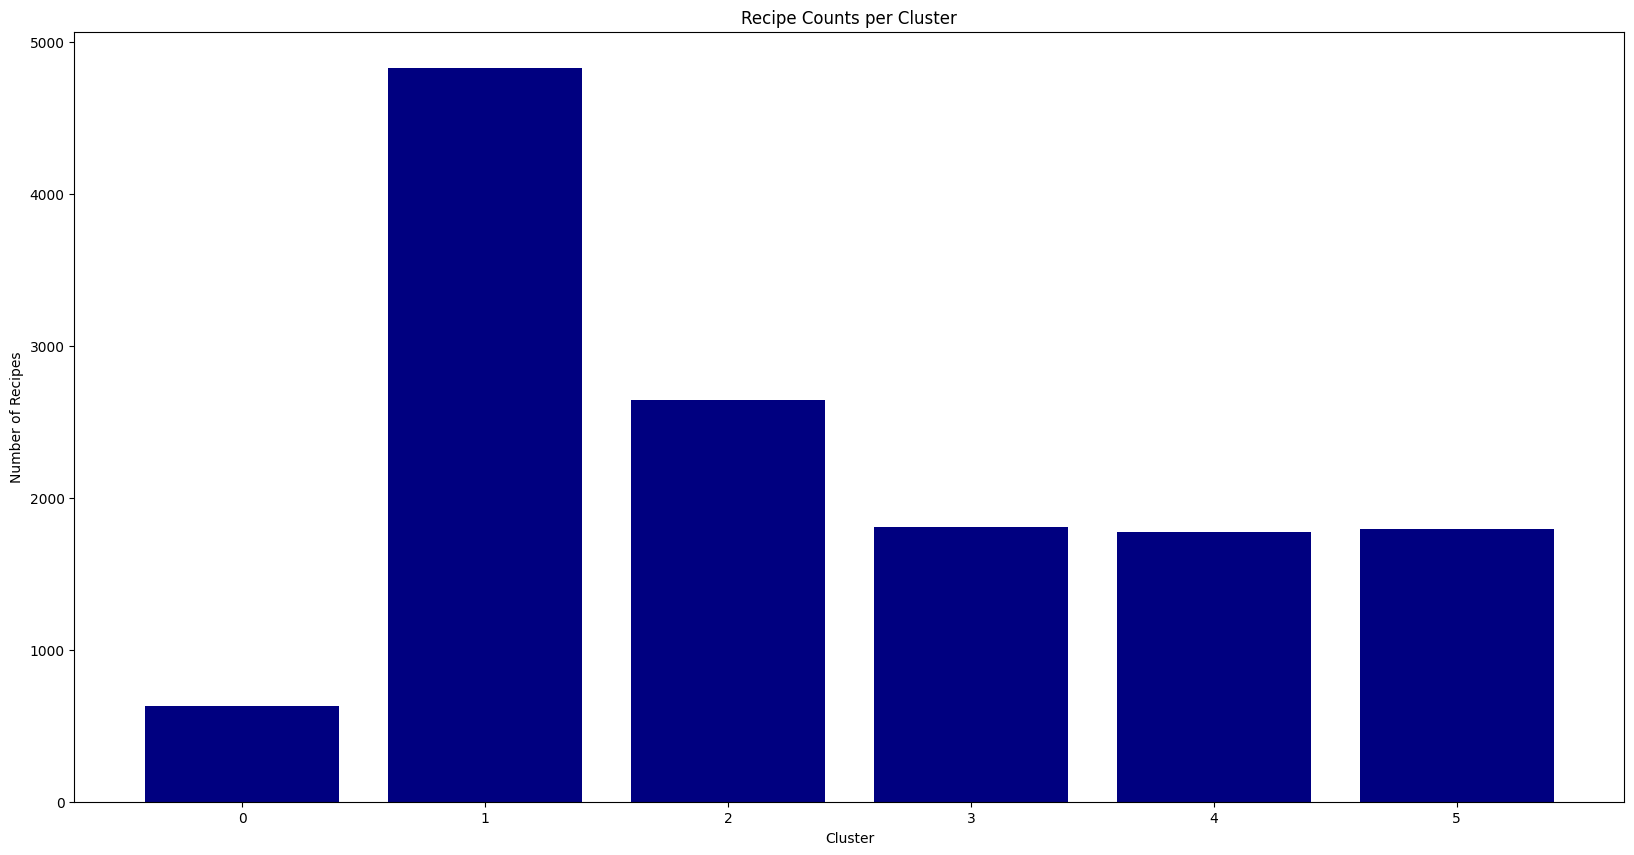

In [345]:
# made bar chart to show it visually
plt.figure(figsize=(20,10))
plt.bar(range(len(cluster_sizes)), cluster_sizes, color='navy')
plt.xlabel("Cluster")
plt.ylabel("Number of Recipes")
plt.title("Recipe Counts per Cluster")
plt.show()

In [346]:
# creates a column cluster to show the label for each recipe
food_ingredient_analysis.head()

,Title,Cleaned_Ingredients,Final_Ingredients_Clean,Cluster
0,Miso-Butter Roast Chicken With Acorn Squash Pa...,"['1 (3½–4-lb.) whole chicken', '2¾ tsp. kosher...","chicken,acorn squash,sage,rosemary,crushed red...",5
1,Crispy Salt and Pepper Potatoes,"['2 large egg whites', '1 pound new potatoes (...","egg whites,potatoes,black pepper,rosemary,thym...",5
2,Thanksgiving Mac and Cheese,"['1 cup evaporated milk', '1 cup whole milk', ...","evaporated milk,milk,garlic,onion,smoked papri...",5
3,Italian Sausage and Bread Stuffing,"['1 (¾- to 1-pound) round Italian loaf, cut in...","italian loaf,sweet italian sausage,casings rem...",2
4,Newton's Law,"['1 teaspoon dark brown sugar', '1 teaspoon ho...","dark brown,hot,bourbon,lemon,apple storebought...",4


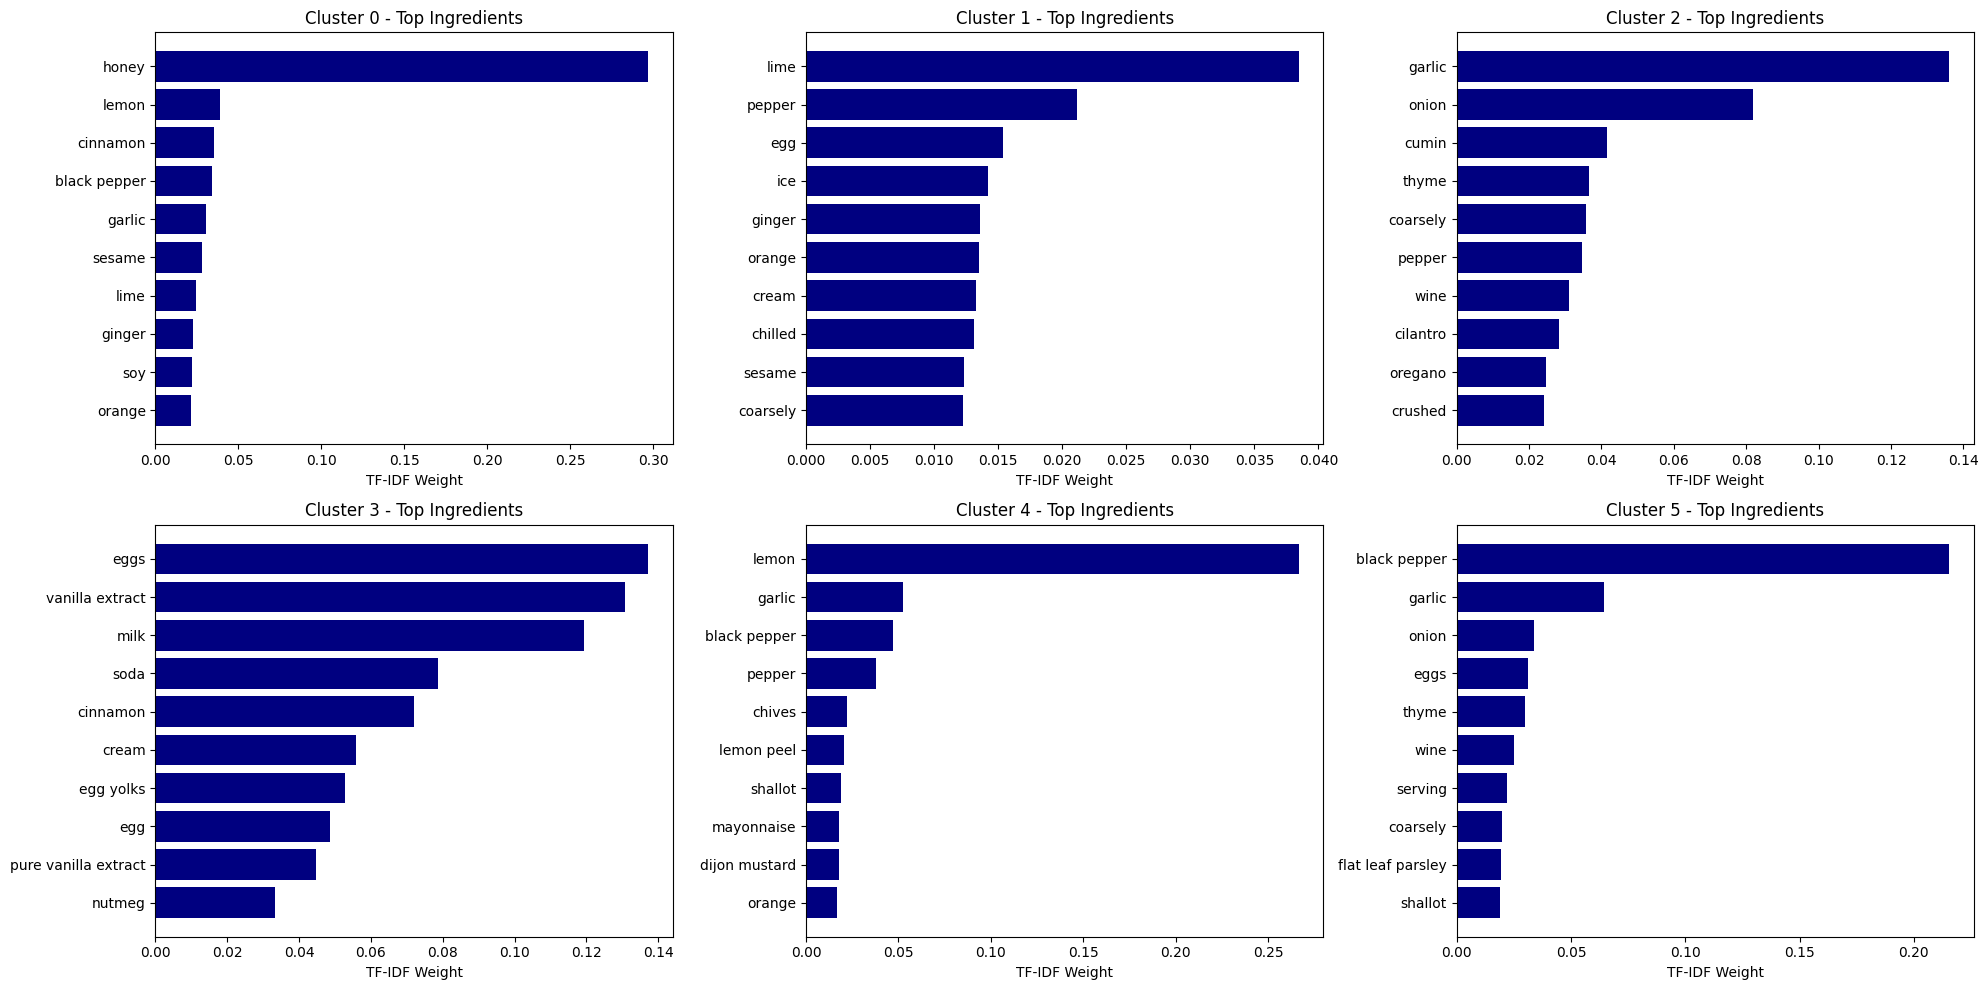

In [348]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))  
axes = axes.flatten()
for cluster in range(6):
    center = kmeans.cluster_centers_[cluster]
    
    # top 10 ingredients
    top_i = center.argsort()[::-1][:10]
    top_terms = [feature_names[i] for i in top_i]
    top_weights = center[top_i]
    
    # horizontal bar chart
    axes[cluster].barh(top_terms[::-1], top_weights[::-1], color='navy')
    axes[cluster].set_title(f"Cluster {cluster} - Top Ingredients")
    axes[cluster].set_xlabel("TF-IDF Weight")

plt.tight_layout()
plt.show()


In [349]:
from sklearn.cluster import AgglomerativeClustering

# Apply Agglomerative Clustering
agg_cluster = AgglomerativeClustering(n_clusters=6, linkage='ward')
labels = agg_cluster.fit_predict(X_tfidf.toarray())

# Attach labels to your DataFrame
food_ingredient_analysis['AggCluster'] = labels

# Print cluster sizes
cluster_sizes = np.bincount(labels)
for i, size in enumerate(cluster_sizes):
    print(f"Agglomerative Cluster {i}: {size} recipes")


Agglomerative Cluster 0: 3291 recipes
Agglomerative Cluster 1: 595 recipes
Agglomerative Cluster 2: 8983 recipes
Agglomerative Cluster 3: 454 recipes
Agglomerative Cluster 4: 38 recipes
Agglomerative Cluster 5: 132 recipes


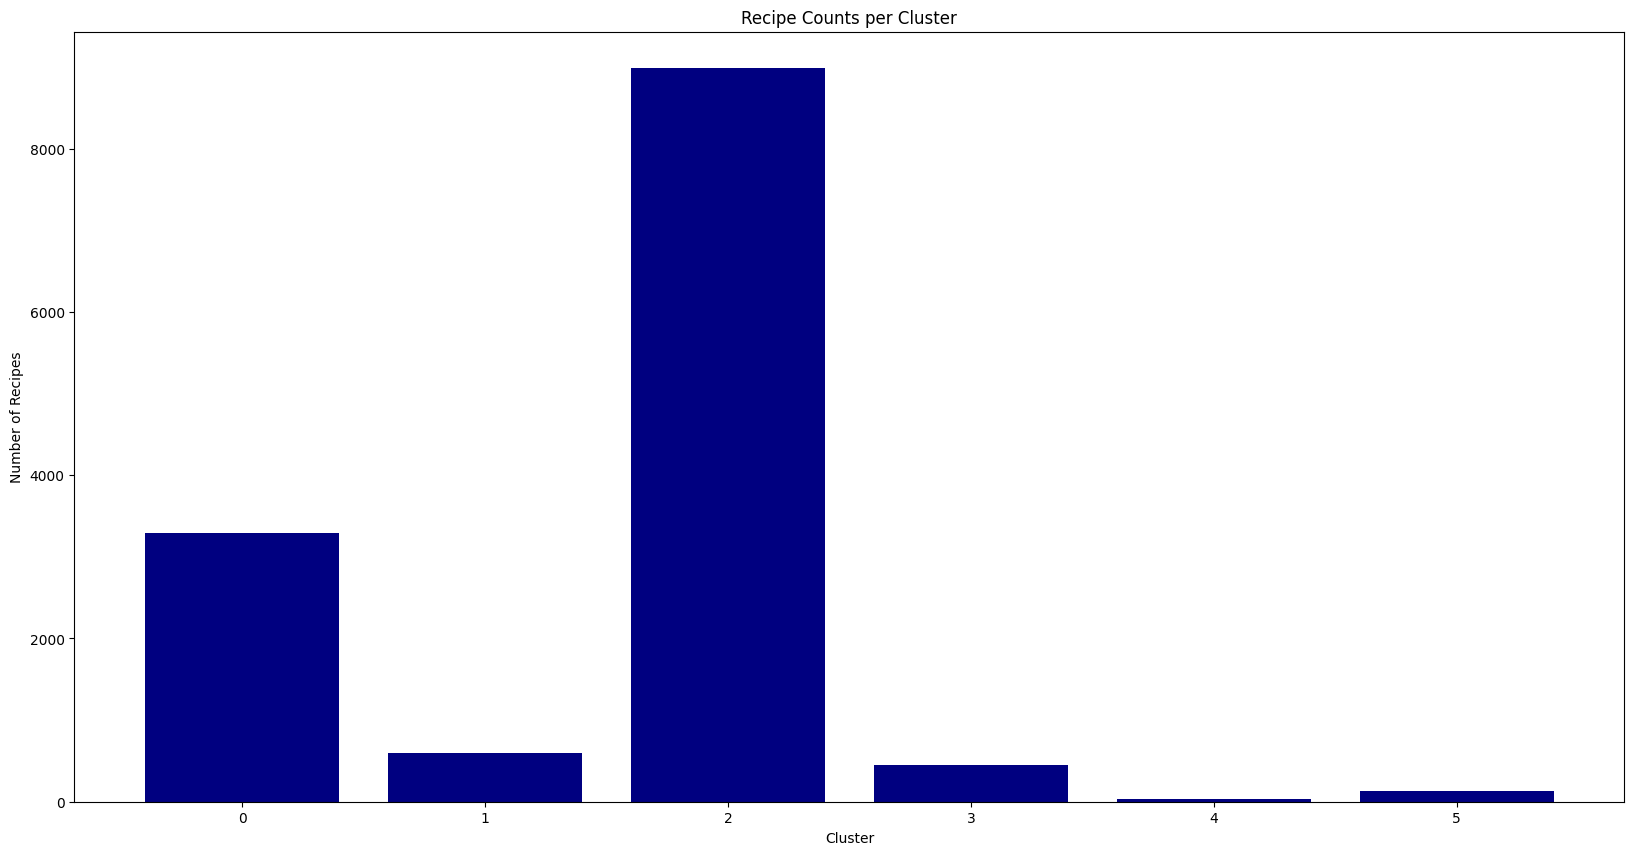

In [325]:
plt.figure(figsize=(20,10))
plt.bar(range(len(cluster_sizes)), cluster_sizes, color='navy')
plt.xlabel("Cluster")
plt.ylabel("Number of Recipes")
plt.title("Recipe Counts per Cluster")
plt.show()

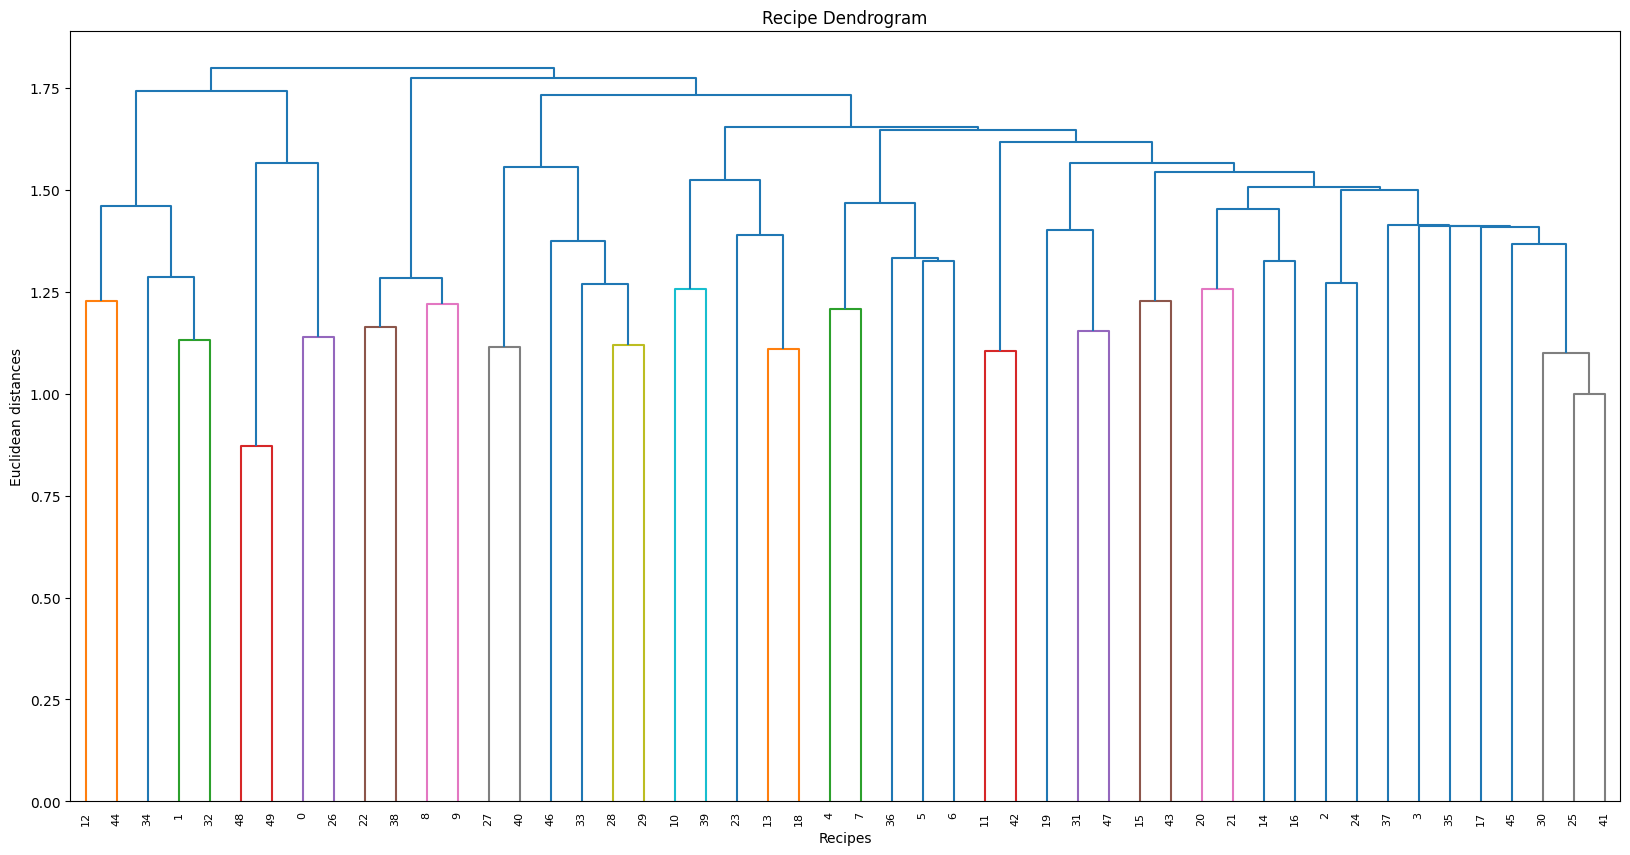

In [ ]:
#dendogram
import scipy.cluster.hierarchy as shc

# only for first 50 recipes
X_subset = X_tfidf.toarray()[:50]

plt.figure(figsize=(20, 10))  
plt.title('Recipe Dendrogram')
plt.xlabel('Recipes')
plt.ylabel('Euclidean distances')

plt.axhline(y=825, color='r', linestyle='--')
plt.axhline(y=1575, color='r', linestyle='--')

dend = shc.dendrogram(shc.linkage(X_subset, method='ward'))
plt.show()